In [1]:
from google.colab import files
uploaded = files.upload()

Saving style.jpg.jpg to style.jpg.jpg
Saving content.jpg.jpg to content.jpg.jpg


Upload content image and style image


Saving style.jpg to style.jpg
Saving content.jpg to content.jpg


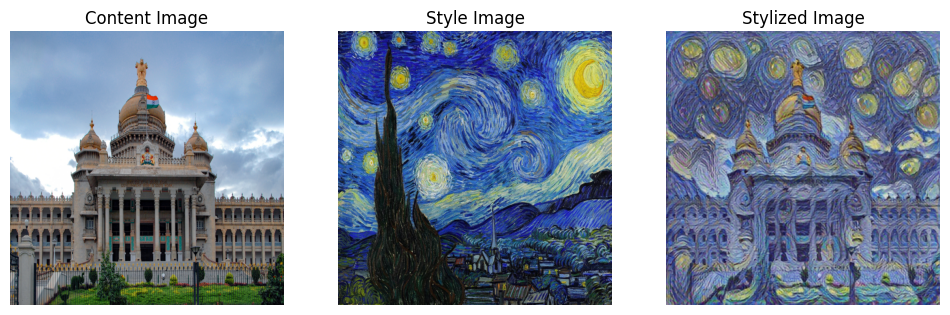

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# Install required libraries
!pip install tensorflow tensorflow_hub matplotlib pillow

# Import libraries
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload images
print("Upload content image and style image")
uploaded = files.upload()

# Function to load and preprocess images
def load_image(image_path, image_size=(512,512)):
    img = Image.open(image_path)
    img = img.resize(image_size)
    img = np.array(img)/255.0
    img = img[np.newaxis, :]
    return tf.convert_to_tensor(img, dtype=tf.float32)

# Load uploaded images
content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

# Load pretrained neural style transfer model
model = hub.load(
'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

# Apply neural style transfer
stylized_image = model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

# Display images
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Content Image")
plt.imshow(content_image[0])
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Style Image")
plt.imshow(style_image[0])
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Stylized Image")
plt.imshow(stylized_image[0])
plt.axis('off')

plt.show()

# Save output image
result = stylized_image[0].numpy()
plt.imsave("stylized_output.png", result)

# Download result
files.download("stylized_output.png")